### PV Secondary Target Selection

## sga_offaxis
### Method to create the secondary targeting file for the off-axis points of large galaxies (from the SGA) in the BGS sample

##### Author: Kelly Douglass (University of Rochester)

See `/project/projectdirs/desi/target/secondary/README` for output data model

### Target classes
1. Mid points on the major axis
2. Mid points on the minor axis
3. Points along the major axis
4. **Points off-axis**

In [18]:
from astropy.table import Table
from astropy.io import fits
from astropy import units as u
from astropy.coordinates import SkyCoord

import numpy as np

import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.projections import get_projection_names

from desiutil.plots import init_sky

import sys
sys.path.insert(1, '/global/homes/k/kadglass/DESI_SGA/')
from legacy_images import get_cutout

## Target catalogs

[Siena Galaxy Atlas](https://www.legacysurvey.org/sga/sga2020/)

In [2]:
# Target catalog file names

# input_directory = '/Users/kellydouglass/Documents/Research/data/SGA/'
input_directory = '/global/cfs/cdirs/cosmo/work/legacysurvey/sga/2025/'

input_filename = input_directory + 'SGA2025-beta-parent-refcat-v1.6.kd.fits'

hdul = fits.open(input_filename)
large_galaxies = hdul[1].data
hdul.close()

## Set fourth priority: points off the major axis

### Large galaxies

We target only those galaxies with $D(26) > 1.4'$ (the fiber patrol radius) along the **semi-minor axis**.

In [3]:
SGA_b = large_galaxies['diam']*large_galaxies['ba']

In [4]:
max_patrol_radius = 1.4 # arcminutes

lg_SGA = large_galaxies[SGA_b >= 2*max_patrol_radius]

In [5]:
lg_SGA_table = Table(lg_SGA)

In [6]:
lg_SGA_table.show_in_notebook()

idx,ra,dec,ref_id,mag,fitmode,pa,ba,diam
0,217.33076888649035,-33.455154340681126,3145667,12.982,0,18.822403,0.6996757,4.2247353
1,215.14209916273919,-29.241798343535308,3145583,12.819,0,153.83276,0.68274856,5.2275467
2,211.87399271844978,-27.017847398537118,3145380,13.681,0,102.39302,0.63419527,5.2181025
3,211.64795695729353,-34.311678749618885,3145361,13.241,0,44.36346,0.8251525,3.47443
4,210.9113490983233,-33.97829916139523,3145296,11.903,0,68.13952,0.5518716,10.471127
5,206.9168910670385,-30.939466846625397,3145033,12.788,0,58.433273,0.8240301,3.8080387
6,207.83063183659095,-33.80819445032636,3145108,12.584,0,134.02795,0.69278973,4.0433764
7,208.22220676165668,-28.48937854649247,3151823,12.708,0,80.37972,0.65694195,5.754336
8,208.99809698239326,-30.341450054692505,3145184,12.98,0,60.412556,0.78042716,3.8003366
9,207.2720719542627,-30.295738628161008,3145067,12.239,0,65.74164,0.5798182,8.185208


In [9]:
lg_SGA_table.write('SGA2025_large_galaxies.fits', format='fits')

### Compare to SGA-2020 list

We don't need to re-inspect the original galaxies, so let's compare this list to that from the SGA-2020 and only keep the new objects.

In [11]:
SGA2020_lg_table = Table.read('../DESI-I_targeting/SGA_large_galaxies.fits')

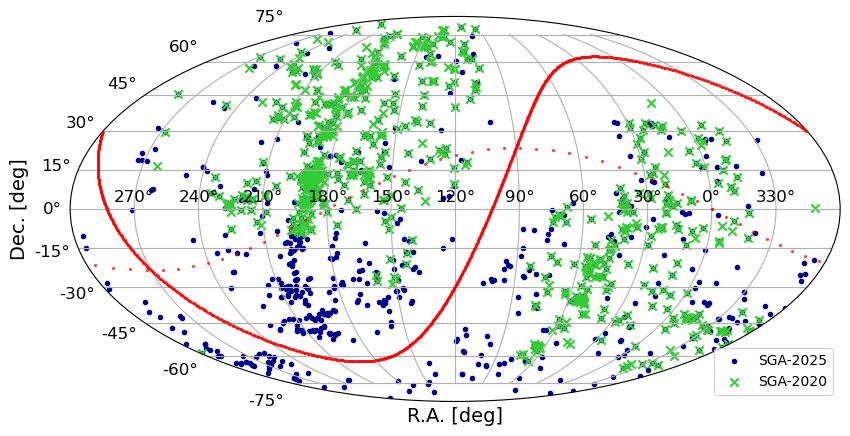

In [22]:
ax = init_sky()

ax.scatter(ax.projection_ra(lg_SGA_table['ra']), 
           ax.projection_dec(lg_SGA_table['dec']), 
           marker='.', 
           color='darkblue', 
           label="SGA-2025")

ax.scatter(ax.projection_ra(SGA2020_lg_table['SGA_RA']), 
           ax.projection_dec(SGA2020_lg_table['SGA_DEC']), 
           marker='x', 
           color='limegreen', 
           label="SGA-2020")

ax.xaxis.label.set_size(14)
ax.yaxis.label.set_size(14)

plt.legend(loc='lower right')

plt.tick_params(axis='both', which='major', labelsize=12);

The two catalogs don't have the same reference numbers, so we need to match by sky coordinate.

In [13]:
SGA2025_centers = SkyCoord(lg_SGA_table['ra']*u.deg, lg_SGA_table['dec']*u.deg)
SGA2020_centers = SkyCoord(SGA2020_lg_table['SGA_RA']*u.deg, SGA2020_lg_table['SGA_DEC']*u.deg)

idx, d2d,_ = SGA2025_centers.match_to_catalog_sky(SGA2020_centers)

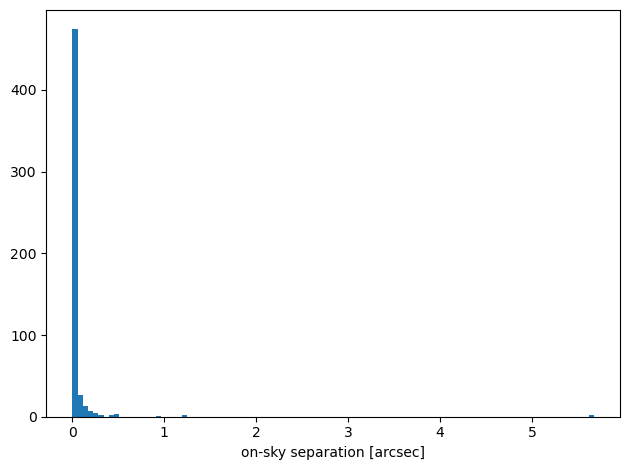

In [39]:
plt.figure(tight_layout=True)

plt.hist(d2d[d2d < 0.1*u.deg].to('arcmin'), bins=100)

plt.xlabel('on-sky separation [arcsec]');

Only keep those objects whose nearest galaxy in the SGA-2020 large galaxy catalog is more than 0.5' away.

In [40]:
new_lg_SGA_table = lg_SGA_table[d2d > 0.5*u.arcmin]

In [41]:
new_lg_SGA_table.show_in_notebook()

idx,ra,dec,ref_id,mag,fitmode,pa,ba,diam
0,217.33076888649035,-33.455154340681126,3145667,12.982,0,18.822403,0.6996757,4.2247353
1,215.14209916273919,-29.241798343535308,3145583,12.819,0,153.83276,0.68274856,5.2275467
2,211.87399271844978,-27.017847398537118,3145380,13.681,0,102.39302,0.63419527,5.2181025
3,211.64795695729353,-34.311678749618885,3145361,13.241,0,44.36346,0.8251525,3.47443
4,210.9113490983233,-33.97829916139523,3145296,11.903,0,68.13952,0.5518716,10.471127
5,206.9168910670385,-30.939466846625397,3145033,12.788,0,58.433273,0.8240301,3.8080387
6,207.83063183659095,-33.80819445032636,3145108,12.584,0,134.02795,0.69278973,4.0433764
7,208.22220676165668,-28.48937854649247,3151823,12.708,0,80.37972,0.65694195,5.754336
8,208.99809698239326,-30.341450054692505,3145184,12.98,0,60.412556,0.78042716,3.8003366
9,207.2720719542627,-30.295738628161008,3145067,12.239,0,65.74164,0.5798182,8.185208


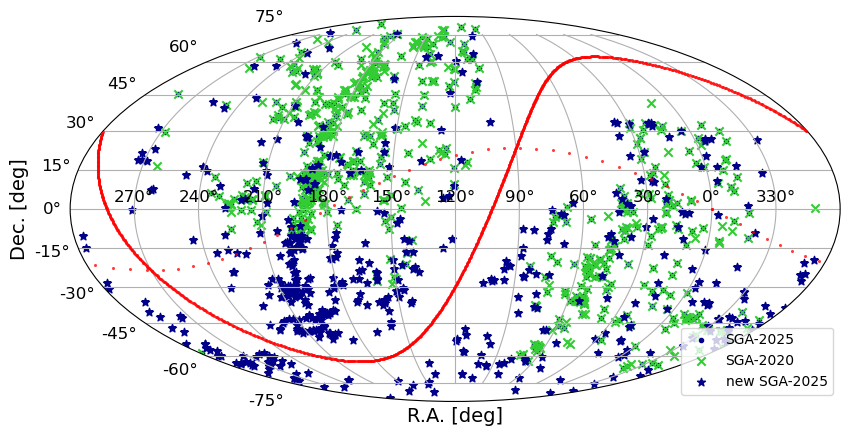

In [43]:
ax = init_sky()

ax.scatter(ax.projection_ra(lg_SGA_table['ra']), 
           ax.projection_dec(lg_SGA_table['dec']), 
           marker='.', 
           color='darkblue', 
           label="SGA-2025")

ax.scatter(ax.projection_ra(SGA2020_lg_table['SGA_RA']), 
           ax.projection_dec(SGA2020_lg_table['SGA_DEC']), 
           marker='x', 
           color='limegreen', 
           label="SGA-2020")

ax.scatter(ax.projection_ra(new_lg_SGA_table['ra']), 
           ax.projection_dec(new_lg_SGA_table['dec']), 
           marker='*', 
           color='darkblue', 
           label="new SGA-2025")

ax.xaxis.label.set_size(14)
ax.yaxis.label.set_size(14)

plt.legend(loc='lower right')

plt.tick_params(axis='both', which='major', labelsize=12);

#### Chunk up galaxy list into sets of 50

In [44]:
for i in range(int(np.ceil(len(new_lg_SGA_table)/50))):
    
    start_idx = i*50
    
    sub_table = new_lg_SGA_table[start_idx : start_idx + 50]
    
    sub_table_filename = 'SGA2025_large_galaxies_' + str(i) + '.fits'
    
    sub_table.write(sub_table_filename, format='fits')

### Extract footprint from Legacy Survey imaging

Accessing Figures/3145296-dr10.jpg
https://www.legacysurvey.org/viewer/cutout.jpg?ra=210.9113490983233&dec=-33.97829916139523&%22/pix=0.25&layer=ls-dr10&size=1000


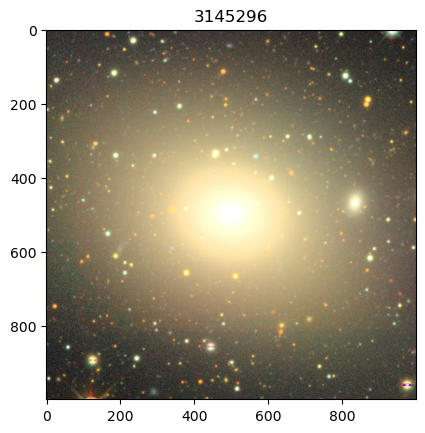

In [49]:
# Single galaxy example

i = 4

img_file = get_cutout(new_lg_SGA_table['ref_id'][i], 
                      new_lg_SGA_table['ra'][i], 
                      new_lg_SGA_table['dec'][i], 
                      dr=10,
                      verbose=True)

img = mpl.image.imread(img_file)

plt.imshow(img)
plt.title('{}'.format(new_lg_SGA_table['ref_id'][i]));